<a href="https://colab.research.google.com/github/maxmigue/machineLearning/blob/main/ProyectoFinalML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto Final - Machine Learning 🧠** | **Clasificación de ritmo cardiaco 🖤**
---

> Miguel Contardo Ramos - 20/06/2025

---


# **Contexto:**

- La	fibrilación	auricular	es	una	condición	en	la	que	el	corazón	late	de	forma	irregular.
- Detectarla	a	tiempo	es	clave	para	prevenir	complicaciones.	En	este	proyecto,	se trabajará	con
señales	reales	de	electrocardiograma	(ECG)	y	desarrollarás	un	clasificador	automático	para
distinguir distintos ritmos según la afección.

# **⛵ Entrega N°1: Exploración inicial**
---


## **1. Datos a trabajar**
- En este caso, se trabajará con archivos .mat (Para almacenar datos que se utilizan en un contexto *MATLAB*) y .hea (archivos de texto que sirven como encabezado para archivos de señal en el formato de archivo WFDB *(Waveform Database Format)*).
- Cada electrocardiograma tiene un archivo .mat y otro .hea, los cuales deben utilizarse en conjunto para obtener tanto la visualización como los datos de la lectura.

> En el siguiente código, se realiza la obtención de cada uno de los registros utilizando su correspondiente archivo .mat y .hea:

In [ ]:
# Instalación de bibliotecas necesarias:
!pip install wfdb matplotlib neurokit2 scipy --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 696.5/696.5 kB 9.3 MB/s eta 0:00:00


Mean RR: 0.7617 s
STD RR: 0.0329 s
Skew RR: 0.1126
Kurtosis RR: -1.2041
Señales: ['ECG']
Frecuencia de muestreo: 300 Hz
Número de muestras: 9000
Forma de los datos: (9000, 1)


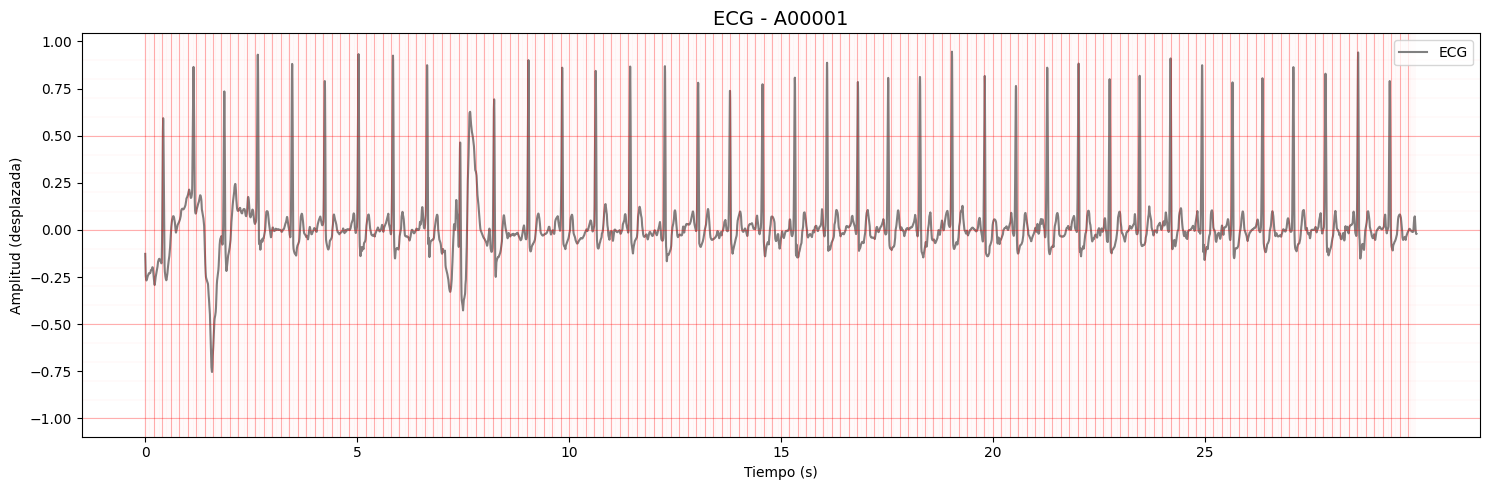

In [ ]:
import wfdb
import neurokit2 as nk
import numpy as np
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt

# Cargar el ECG
record_name = 'A00001'
record = wfdb.rdrecord(record_name)
ecg_signal = record.p_signal[:, 0]  # Usa la primera derivación
fs = record.fs  # Frecuencia de muestreo

# Procesar señal con NeuroKit2
ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate=fs)
signals, info = nk.ecg_process(ecg_cleaned, sampling_rate=fs)

# Obtener ubicaciones de los picos R
r_peaks = info['ECG_R_Peaks']

# Calcular intervalos RR en segundos
rr_intervals = np.diff(r_peaks) / fs

# Estadísticas
mean_rr = np.mean(rr_intervals)
std_rr = np.std(rr_intervals)
skew_rr = skew(rr_intervals)
kurt_rr = kurtosis(rr_intervals)

# Mostrar resultados
print(f"Mean RR: {mean_rr:.4f} s")
print(f"STD RR: {std_rr:.4f} s")
print(f"Skew RR: {skew_rr:.4f}")
print(f"Kurtosis RR: {kurt_rr:.4f}")

# Muestra información básica
print(f"Señales: {record.sig_name}")
print(f"Frecuencia de muestreo: {record.fs} Hz")
print(f"Número de muestras: {record.sig_len}")
print(f"Forma de los datos: {record.p_signal.shape}")

n_samples = record.p_signal.shape[0]
time = np.arange(n_samples) / fs

plt.figure(figsize=(15, 5))

# Graficar cada señal desplazada verticalmente
for i in range(record.n_sig):
    signal = record.p_signal[:, i]
    plt.plot(time, signal + i * 2, label=record.sig_name[i], color='gray')  # desplazar para que no se encimen

# Título y etiquetas
plt.title(f"ECG - {record_name}", fontsize=14)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (desplazada)")

# Leyenda
plt.legend(loc='upper right')

# Papel milimetrado: líneas gruesas cada 0.2s y 0.5 mV, líneas finas cada 0.04s y 0.1 mV

# Líneas verticales gruesas (cada 0.2 s)
for x in np.arange(0, time[-1], 0.2):
    plt.axvline(x=x, color='red', linewidth=0.8, alpha=0.3)

# Líneas verticales finas (cada 0.04 s)
for x in np.arange(0, time[-1], 0.04):
    plt.axvline(x=x, color='red', linewidth=0.3, alpha=0.1)

# Líneas horizontales gruesas (cada 0.5 unidades, depende de la amplitud)
ymin = np.min(record.p_signal)
ymax = np.max(record.p_signal) + (record.n_sig - 1) * 2
for y in np.arange(np.floor(ymin), np.ceil(ymax), 0.5):
    plt.axhline(y=y, color='red', linewidth=0.8, alpha=0.3)

# Líneas horizontales finas (cada 0.1 unidades)
for y in np.arange(np.floor(ymin), np.ceil(ymax), 0.1):
    plt.axhline(y=y, color='red', linewidth=0.3, alpha=0.1)

# Configurar ticks del eje X para que no se vean cada segundo
plt.xticks(np.arange(0, time[-1], 5))

plt.grid(False)
plt.tight_layout()
plt.show()